# Detección de Acordes Polifónicos de Guitarra Acústica de Cuerdas de 

El objetivo de este proyecto es desarrollar un sistema basado en Inteligencia Artificial capaz de "escuchar" una pista de audio de guitarra acústica y transcribir automáticamente los acordes que están sonando.

### Metodología
Este proyecto aborda el problema de la transcripción musical automática estructurándolo como un flujo de clasificación supervisada de imágenes:
1. **Preprocesamiento de Audio (Librosa):** Transformamos las ondas de audio unidimensionales (`.wav`) al dominio de frecuencia-tiempo utilizando la **Transformada Constant-Q (CQT)**. Esto genera espectrogramas en escala logarítmica (dB) diseñados para representar fielmente las notas y armónicos musicales.

2. **Dataset (GuitarSet):** Utilizamos el dataset de código abierto *GuitarSet*, del cual segmentamos ventanas de 0.5 segundos y sus correspondientes anotaciones extraídas de archivos `.jams`.

3. **Clasificación (PyTorch):** Reducimos la taxonomía a **25 clases** fundamentales (12 Mayores, 12 Menores y Sin Acorde) y entrenamos una **Red Neuronal Convolucional 2D (CNN)** para que aprenda los patrones visuales y armónicos que definen cada acorde.

In [14]:
%pip install torch librosa pandas scikit-learn seaborn matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# 1. Utilidades de sistema y Python estándar
import os
import json
import glob
import time

# 2. Computación numérica y matemáticas
import numpy as np

# 3. Procesamiento de audio y representación musical
import librosa
import librosa.display
from scipy.signal import butter, sosfiltfilt

# 4. PyTorch (Deep Learning y DataLoaders)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 5. Interfaces de usuario y visualización en Jupyter
import ipywidgets as widgets
from IPython.display import display, Audio, clear_output
import matplotlib.pyplot as plt

# Configuraciones adicionales
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)


## Análisis Exploratorio del Dataset

#### Directorio

In [16]:
# Constants and path utilities
PATH = "../GuitarSet/3371780"

def get_audio_folders(base_path):
    """Returns a sorted list of audio directories within the base path."""
    return sorted([
        f for f in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, f)) and f.startswith("audio")
    ])

def get_audio_files(folder_path):
    """Returns a sorted list of .wav files in the specified directory."""
    return sorted([f for f in os.listdir(folder_path) if f.endswith('.wav')])


#### Explorador y visualizador del dataset

In [17]:
# Audio processing and visualization state
class AudioVisualizer:
    """Handles audio loading, CQT computation, and spectrogram rendering."""

    def __init__(self):
        self.cqt_db = None
        self.sr = 44100
        self.hop_length = 512
        self.fmin = librosa.note_to_hz('C2')
        self.duration = 0.0

    def load_and_compute(self, file_path):
        """Loads audio and computes CQT, storing it in memory to optimize panning/zooming."""
        y, self.sr = librosa.load(file_path, sr=44100)
        self.duration = librosa.get_duration(y=y, sr=self.sr)

        n_bins = 84
        cqt_matrix = librosa.cqt(
            y, sr=self.sr, fmin=self.fmin, n_bins=n_bins,
            bins_per_octave=12, hop_length=self.hop_length
        )
        self.cqt_db = librosa.amplitude_to_db(np.abs(cqt_matrix), ref=np.max)

    def plot_spectrogram(self, start_time, window_size):
        """Displays the computed spectrogram sliced by the current time window."""
        if self.cqt_db is None:
            return

        fig, ax = plt.subplots(figsize=(14, 6))
        img = librosa.display.specshow(
            self.cqt_db, sr=self.sr, x_axis='time', y_axis='cqt_note',
            fmin=self.fmin, cmap='coolwarm', ax=ax, hop_length=self.hop_length
        )

        # Apply time axis boundaries
        ax.set_xlim(start_time, start_time + window_size)

        ax.set_title('Constant-Q Transform (CQT) Spectrogram')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Pitch')
        fig.colorbar(img, ax=ax, format="%+2.0f dB")

        plt.tight_layout()
        plt.show()

# Global instance to persist state across widget interactions
visualizer = AudioVisualizer()


In [18]:
# Interactive explorer interface

# Internal state for zoom level
zoom_state = {'window_size': 10.0}

audio_folders = get_audio_folders(PATH)

# File selection controls
folder_dropdown = widgets.Dropdown(
    options=audio_folders, description='Folder:',
    layout=widgets.Layout(width='300px')
)

file_dropdown = widgets.Dropdown(
    options=[], description='Track:',
    layout=widgets.Layout(width='400px')
)

# Navigation controls
zoom_in_btn = widgets.Button(
    description='Zoom In (+)', icon='search-plus',
    layout=widgets.Layout(width='120px')
)

zoom_out_btn = widgets.Button(
    description='Zoom Out (-)', icon='search-minus',
    layout=widgets.Layout(width='120px')
)

pan_slider = widgets.FloatSlider(
    value=0.0, min=0.0, max=10.0, step=0.1,
    description='Timeline:',
    continuous_update=False, # Wait for drag release before rendering
    layout=widgets.Layout(width='600px')
)

# Display areas
output_audio = widgets.Output()
output_plot = widgets.Output()

def update_slider_bounds():
    """Adjusts the panning slider constraints based on duration and zoom window."""
    if visualizer.duration > 0:
        max_start = max(0.0, visualizer.duration - zoom_state['window_size'])
        pan_slider.max = max_start
        if pan_slider.value > max_start:
            pan_slider.value = max_start

def on_folder_change(change):
    """Updates the track list when the source folder changes."""
    selected_folder = change['new']
    if selected_folder:
        folder_path = os.path.join(PATH, selected_folder)
        files = get_audio_files(folder_path)
        file_dropdown.options = files
        if files:
            file_dropdown.value = files[0]

def on_file_change(change):
    """Loads new audio, resets zoom state, and triggers initial render."""
    selected_folder = folder_dropdown.value
    selected_file = file_dropdown.value

    if not selected_folder or not selected_file:
        return

    file_path = os.path.join(PATH, selected_folder, selected_file)

    with output_audio:
        clear_output(wait=True)
        display(Audio(filename=file_path))

    visualizer.load_and_compute(file_path)

    # Reset zoom and timeline defaults
    zoom_state['window_size'] = min(10.0, visualizer.duration)

    pan_slider.unobserve(on_pan_change, names='value')
    pan_slider.value = 0.0
    update_slider_bounds()
    pan_slider.observe(on_pan_change, names='value')

    render_plot()

def on_zoom_in(b):
    """Halves the visible window size and re-renders."""
    if zoom_state['window_size'] > 0.5:
        zoom_state['window_size'] /= 2.0
        update_slider_bounds()
        render_plot()

def on_zoom_out(b):
    """Doubles the visible window size and re-renders."""
    if zoom_state['window_size'] < visualizer.duration:
        zoom_state['window_size'] = min(visualizer.duration, zoom_state['window_size'] * 2.0)
        update_slider_bounds()
        render_plot()

def on_pan_change(change):
    """Re-renders the plot sliced at the new timeline position."""
    render_plot()

def render_plot():
    """Renders the spectrogram slice within the designated output widget."""
    with output_plot:
        clear_output(wait=True)
        visualizer.plot_spectrogram(
            start_time=pan_slider.value,
            window_size=zoom_state['window_size']
        )

# Bind widget events
folder_dropdown.observe(on_folder_change, names='value')
file_dropdown.observe(on_file_change, names='value')
zoom_in_btn.on_click(on_zoom_in)
zoom_out_btn.on_click(on_zoom_out)
pan_slider.observe(on_pan_change, names='value')

# Trigger initial startup sequence
on_folder_change({'new': folder_dropdown.value})

# Layout assembly
controls_box = widgets.HBox([folder_dropdown, file_dropdown])
zoom_box = widgets.HBox([zoom_out_btn, zoom_in_btn, pan_slider])

display(widgets.VBox([
    controls_box,
    output_audio,
    zoom_box,
    output_plot
]))


## Preprocesamiento para CNN-2S

Este bloque construye el preprocesamiento espectral para entrenamiento posterior: segmenta en ventanas de 0.5 s con 50% de solapamiento, aplica un filtrado básico, genera CQT, chroma y energia armonica, y normaliza cada segmento antes de devolverlo listo para la red.

Preprocesamiento CNN-2S listo: CQT + chroma + energia armonica + segmentacion de 0.5 s.
Ejemplo de datos preprocesados:
Track: 00_BN1-129-Eb_comp
Etiqueta: D# (3)
Ventana temporal: 0.00s - 0.50s
Spectrogram shape: (1, 84, 43)
Chroma shape: (1, 12, 43)
Harmonic energy shape: (1, 12, 43)
Aux stream shape: (2, 12, 43)


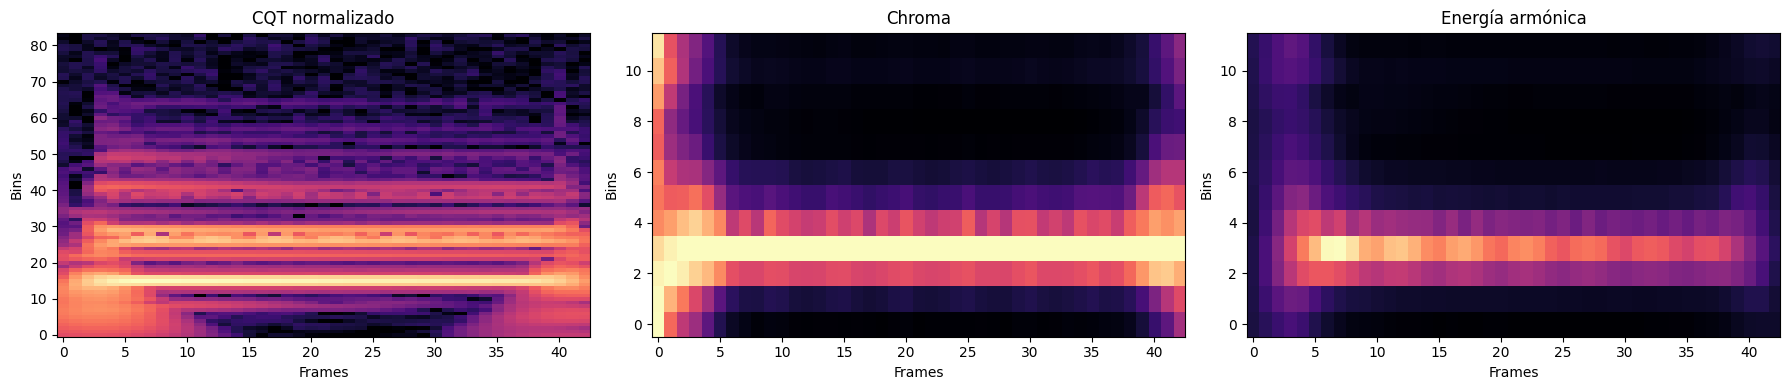

In [19]:
# Preprocesamiento para CNN-2S

CHROMATIC_NOTES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
FLAT_TO_SHARP = {
    'Db': 'C#', 'Eb': 'D#', 'Gb': 'F#', 'Ab': 'G#', 'Bb': 'A#'
}


def get_chord_mapping():
    """Creates the 25-class mapping used for chord labels."""
    mapping = {}
    for idx, note in enumerate(CHROMATIC_NOTES):
        mapping[note] = idx
    for idx, note in enumerate(CHROMATIC_NOTES):
        mapping[note + 'm'] = idx + 12
    mapping['N'] = 24
    idx_to_chord = CHROMATIC_NOTES + [note + 'm' for note in CHROMATIC_NOTES] + ['N']
    return mapping, idx_to_chord


CHORD_MAP, IDX_TO_CHORD = get_chord_mapping()


def simplify_jams_chord(chord_str):
    """Converts a JAMS chord label to one of the 25 simplified classes."""
    if not chord_str or chord_str == 'N' or str(chord_str).startswith('silence'):
        return 'N'

    parts = str(chord_str).split(':')
    root = FLAT_TO_SHARP.get(parts[0], parts[0])
    if root not in CHROMATIC_NOTES:
        return 'N'

    quality = parts[1].lower() if len(parts) > 1 else 'maj'
    if 'min' in quality or quality == 'm':
        return root + 'm'
    return root


def load_chord_timeline(jams_path):
    """Loads chord annotations from a .jams file."""
    with open(jams_path, 'r', encoding='utf-8') as f:
        jams_data = json.load(f)

    timeline = []
    for annotation in jams_data.get('annotations', []):
        if annotation.get('namespace') == 'chord':
            for observation in annotation.get('data', []):
                start_time = observation.get('time', 0.0)
                duration = observation.get('duration', 0.0)
                timeline.append({
                    'start': start_time,
                    'end': start_time + duration,
                    'chord': simplify_jams_chord(observation.get('value'))
                })
            break
    return timeline


def find_active_chord(chords_timeline, time_point):
    """Returns the active chord at a given time point."""
    for chord_event in chords_timeline:
        if chord_event['start'] <= time_point <= chord_event['end']:
            return chord_event['chord']
    return 'N'


def basic_audio_filter(y, sr, cutoff_hz=70.0, order=4):
    """Applies a basic high-pass filter to reduce low-frequency rumble."""
    y = np.asarray(y, dtype=np.float32)
    if y.size == 0 or cutoff_hz <= 0:
        return y

    sos = butter(order, cutoff_hz, btype='highpass', fs=sr, output='sos')
    filtered = sosfiltfilt(sos, y)
    filtered = filtered - np.mean(filtered)
    return filtered.astype(np.float32)


def get_target_frames(frame_duration=0.5, sr=44100, hop_length=512):
    """Computes the target number of time frames for each segment."""
    return int(round(frame_duration * sr / hop_length))


def segment_audio(y, sr, frame_duration=0.5, overlap=0.5):
    """Splits a waveform into fixed-size overlapping windows."""
    frame_samples = int(round(frame_duration * sr))
    stride_samples = max(1, int(round(frame_samples * (1 - overlap))))

    segments = []
    start_sample = 0
    while start_sample + frame_samples <= len(y):
        end_sample = start_sample + frame_samples
        segments.append((start_sample, end_sample))
        start_sample += stride_samples

    return segments, frame_samples, stride_samples


def normalize_feature_map(feature, eps=1e-8):
    """Scales a 2D feature map to [0, 1] per segment."""
    feature = np.asarray(feature, dtype=np.float32)
    min_value = np.min(feature)
    max_value = np.max(feature)
    if max_value - min_value < eps:
        return np.zeros_like(feature, dtype=np.float32)
    return ((feature - min_value) / (max_value - min_value + eps)).astype(np.float32)


def extract_cqt_feature(segment, sr, hop_length=512, fmin=None, n_bins=84, target_frames=None):
    """Computes the normalized CQT spectrogram for one segment."""
    if fmin is None:
        fmin = librosa.note_to_hz('C2')
    if target_frames is None:
        target_frames = get_target_frames(sr=sr, hop_length=hop_length)

    cqt = librosa.cqt(
        segment,
        sr=sr,
        fmin=fmin,
        n_bins=n_bins,
        bins_per_octave=12,
        hop_length=hop_length
    )
    cqt_db = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)
    cqt_db = librosa.util.fix_length(cqt_db, size=target_frames, axis=1)
    return normalize_feature_map(cqt_db), cqt_db


def extract_chroma_feature(segment, sr, hop_length=512, target_frames=None):
    """Computes the normalized chroma feature map for one segment."""
    if target_frames is None:
        target_frames = get_target_frames(sr=sr, hop_length=hop_length)

    chroma = librosa.feature.chroma_cqt(
        y=segment,
        sr=sr,
        hop_length=hop_length,
        bins_per_octave=12,
        n_chroma=12
    )
    chroma = librosa.util.fix_length(chroma, size=target_frames, axis=1)
    return normalize_feature_map(chroma)


def extract_harmonic_energy(cqt_db, target_frames=None):
    """Builds a simple harmonic-energy map from the CQT magnitude."""
    cqt_mag = librosa.db_to_amplitude(cqt_db)
    harmonic_energy = np.zeros((12, cqt_mag.shape[1]), dtype=np.float32)

    for bin_idx in range(cqt_mag.shape[0]):
        pitch_class = bin_idx % 12
        octave_weight = 1.0 / (1.0 + (bin_idx // 12))
        harmonic_energy[pitch_class] += cqt_mag[bin_idx] * octave_weight

    if target_frames is not None:
        harmonic_energy = librosa.util.fix_length(harmonic_energy, size=target_frames, axis=1)

    return normalize_feature_map(harmonic_energy)


def extract_segment_features(segment, sr, hop_length=512, frame_duration=0.5):
    """Returns the two-stream inputs for CNN-2S from one audio segment."""
    target_frames = get_target_frames(frame_duration=frame_duration, sr=sr, hop_length=hop_length)
    spectrogram, cqt_db = extract_cqt_feature(
        segment,
        sr,
        hop_length=hop_length,
        target_frames=target_frames
    )
    chroma = extract_chroma_feature(
        segment,
        sr,
        hop_length=hop_length,
        target_frames=target_frames
    )
    harmonic_energy = extract_harmonic_energy(cqt_db, target_frames=target_frames)

    return {
        'spectrogram': spectrogram[np.newaxis, :, :],
        'chroma': chroma[np.newaxis, :, :],
        'harmonic_energy': harmonic_energy[np.newaxis, :, :],
        'aux_stream': np.stack([chroma, harmonic_energy], axis=0),
    }


def preprocess_track_for_cnn2s(
    audio_path,
    jams_path=None,
    sr=44100,
    frame_duration=0.5,
    overlap=0.5,
    hop_length=512
):
    """Preprocesses one track into overlapping samples ready for CNN-2S."""
    y, sr = librosa.load(audio_path, sr=sr, mono=True)
    y = basic_audio_filter(y, sr)

    chords_timeline = load_chord_timeline(jams_path) if jams_path and os.path.exists(jams_path) else []
    windows, _, _ = segment_audio(y, sr, frame_duration=frame_duration, overlap=overlap)

    processed_samples = []
    for start_sample, end_sample in windows:
        segment = y[start_sample:end_sample]
        features = extract_segment_features(
            segment,
            sr,
            hop_length=hop_length,
            frame_duration=frame_duration
        )

        center_time = ((start_sample + end_sample) / 2.0) / sr
        active_chord = find_active_chord(chords_timeline, center_time) if chords_timeline else 'N'
        label_idx = CHORD_MAP.get(active_chord, CHORD_MAP['N'])

        features.update({
            'label': label_idx,
            'label_name': IDX_TO_CHORD[label_idx],
            'start_time': start_sample / sr,
            'end_time': end_sample / sr
        })
        processed_samples.append(features)

    return processed_samples


def build_cnn2s_dataset(
    base_dir,
    track_names,
    audio_type='audio_mono-pickup_mix',
    sr=44100,
    frame_duration=0.5,
    overlap=0.5,
    hop_length=512
):
    """Builds a dataset list with tensors for the spectral and auxiliary streams."""
    samples = []
    labels = []
    metadata = []

    for track in track_names:
        audio_file = f'{track}_mix.wav' if 'mix' in audio_type else f'{track}_mic.wav'
        audio_path = os.path.join(base_dir, audio_type, audio_file)
        jams_path = os.path.join(base_dir, 'annotation', f'{track}.jams')

        if not os.path.exists(audio_path) or not os.path.exists(jams_path):
            continue

        track_samples = preprocess_track_for_cnn2s(
            audio_path=audio_path,
            jams_path=jams_path,
            sr=sr,
            frame_duration=frame_duration,
            overlap=overlap,
            hop_length=hop_length
        )

        for sample in track_samples:
            samples.append({
                'spectrogram': torch.tensor(sample['spectrogram'], dtype=torch.float32),
                'aux_stream': torch.tensor(sample['aux_stream'], dtype=torch.float32)
            })
            labels.append(sample['label'])
            metadata.append({
                'track': track,
                'label_name': sample['label_name'],
                'start_time': sample['start_time'],
                'end_time': sample['end_time']
            })

    return samples, labels, metadata


print('Preprocesamiento CNN-2S listo: CQT + chroma + energia armonica + segmentacion de 0.5 s.')

# Vista previa de una muestra preprocesada para validar que la celda produce datos observables.
preview_track = None
annotation_dir = os.path.join(PATH, 'annotation')
if os.path.isdir(annotation_dir):
    annotation_files = sorted([name for name in os.listdir(annotation_dir) if name.endswith('.jams')])
    if annotation_files:
        preview_track = os.path.splitext(annotation_files[0])[0]

if preview_track is None:
    print('No se encontraron anotaciones JAMS para generar una vista previa.')
else:
    preview_audio_path = os.path.join(PATH, 'audio_mono-pickup_mix', f'{preview_track}_mix.wav')
    preview_jams_path = os.path.join(PATH, 'annotation', f'{preview_track}.jams')

    if not os.path.exists(preview_audio_path):
        print(f'No se encontró el audio de vista previa: {preview_audio_path}')
    else:
        preview_samples = preprocess_track_for_cnn2s(
            audio_path=preview_audio_path,
            jams_path=preview_jams_path,
            sr=44100,
            frame_duration=0.5,
            overlap=0.5,
            hop_length=512
        )

        if not preview_samples:
            print('La preprocesamiento no generó ventanas para la muestra seleccionada.')
        else:
            preview_sample = preview_samples[0]
            spectrogram = preview_sample['spectrogram'][0]
            chroma = preview_sample['chroma'][0]
            harmonic_energy = preview_sample['harmonic_energy'][0]

            print('Ejemplo de datos preprocesados:')
            print(f"Track: {preview_track}")
            print(f"Etiqueta: {preview_sample['label_name']} ({preview_sample['label']})")
            print(f"Ventana temporal: {preview_sample['start_time']:.2f}s - {preview_sample['end_time']:.2f}s")
            print(f"Spectrogram shape: {preview_sample['spectrogram'].shape}")
            print(f"Chroma shape: {preview_sample['chroma'].shape}")
            print(f"Harmonic energy shape: {preview_sample['harmonic_energy'].shape}")
            print(f"Aux stream shape: {preview_sample['aux_stream'].shape}")

            fig, axes = plt.subplots(1, 3, figsize=(18, 4))
            images = [spectrogram, chroma, harmonic_energy]
            titles = ['CQT normalizado', 'Chroma', 'Energía armónica']
            for axis, image, title in zip(axes, images, titles):
                axis.imshow(image, aspect='auto', origin='lower', cmap='magma')
                axis.set_title(title)
                axis.set_xlabel('Frames')
                axis.set_ylabel('Bins')
            plt.tight_layout()
            plt.show()
